데이터를 불러오는 중입니다...

모델 학습을 시작합니다...
학습 완료!

        🏆 Validation 세트 평가 결과
Log Loss : 0.1523
ROC-AUC  : 0.9755
F1-score : 0.6182
Accuracy : 0.9246

[Confusion Matrix]
[[142548  11770]
 [   679  10077]]

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    154318
           1       0.46      0.94      0.62     10756

    accuracy                           0.92    165074
   macro avg       0.73      0.93      0.79    165074
weighted avg       0.96      0.92      0.94    165074


     🌟 Top 10 Feature Importances
              Feature  Importance
         tx_is_cancel    0.320795
     tx_is_auto_renew    0.246906
       tx_trans_count    0.177239
         tx_trans_day    0.097225
      tx_expire_month    0.040507
        tx_pp_days_30    0.037157
tx_actual_amount_paid    0.022230
       tx_trans_month    0.013424
        tx_expire_day    0.011587
        tx_trans_year    0.010357


C:\Users\Playdata\AppData\Local\Temp\ipykernel_5104\533953295.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top10_features, palette='viridis')


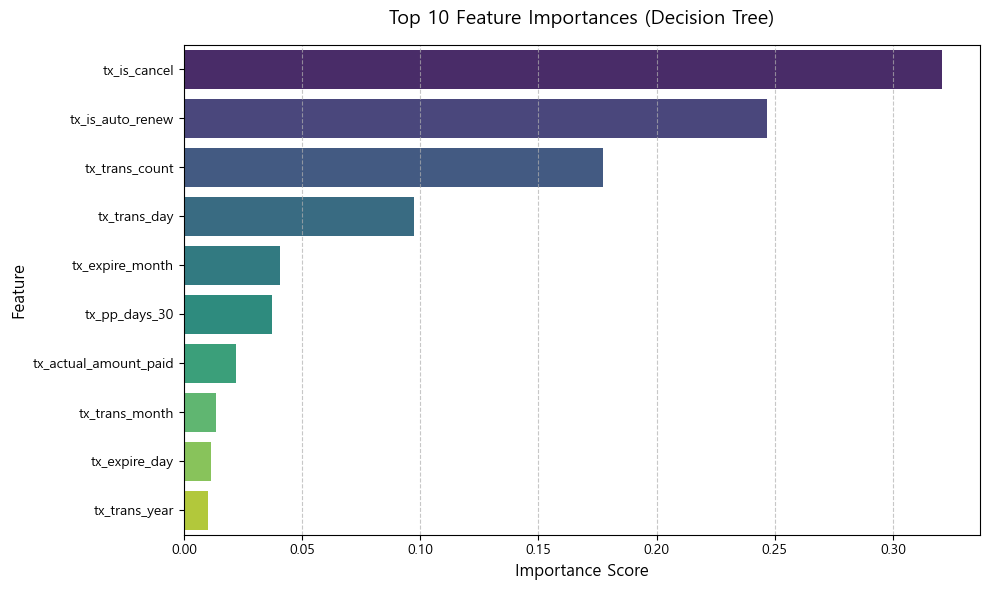


✅ Validation 모델 성능 지표가 'results/dt_performance_val.csv'에 저장되었습니다.


In [27]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, log_loss, roc_curve,
    accuracy_score, precision_score, recall_score
)

# 1. 분할된 데이터 불러오기 (Test 세트는 이번 단계에서 제외)
print("데이터를 불러오는 중입니다...")
train_df = pd.read_csv("./data/train.csv")
val_df = pd.read_csv("./data/val.csv")
# test_df = pd.read_csv("./data/test.csv") # 보류

# 2. X, y 분리 및 불필요한 컬럼 제거 함수 정의
def prepare_data(df):
    drop_cols = [
        "msno", "is_churn", 
        "last_tx_date", "last_expire_date", "last_listen_date",
        
        # 👇👇👇 바로 이곳! 앞에 'tx_'를 붙여 실제 컬럼명과 완벽히 똑같이 맞췄습니다.
        "tx_transaction_date", 
        "tx_membership_expire_date", 
        "registration_init_time" # (이 컬럼도 문자형이라면 지워주세요)
    ]
    # 존재하는 컬럼만 골라서 삭제
    cols_to_drop = [col for col in drop_cols if col in df.columns]
    
    X = df.drop(columns=cols_to_drop)
    y = df["is_churn"]
    return X, y

X_train, y_train = prepare_data(train_df)
X_val, y_val = prepare_data(val_df)

# 3. 결측치 처리 및 원-핫 인코딩 (더미화)
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)

# ★ 중요: Train 세트 컬럼을 기준으로 Val 세트 컬럼 맞추기
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

# 4. Decision Tree 모델 생성 및 학습
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42
)

print("\n모델 학습을 시작합니다...")
dt_model.fit(X_train, y_train)
print("학습 완료!")

# 5. ★ Test 대신 Val 세트로 예측 수행 ★
pred_val = dt_model.predict(X_val)
pred_proba_val = dt_model.predict_proba(X_val)[:, 1]

# 6. 평가 지표 출력 (Val 세트 기준)
print("\n" + "="*40)
print("        🏆 Validation 세트 평가 결과")
print("="*40)
print(f"Log Loss : {log_loss(y_val, pred_proba_val):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, pred_proba_val):.4f}")
print(f"F1-score : {f1_score(y_val, pred_val):.4f}")
print(f"Accuracy : {accuracy_score(y_val, pred_val):.4f}")

print("\n[Confusion Matrix]")
print(confusion_matrix(y_val, pred_val))

print("\n[Classification Report]")
print(classification_report(y_val, pred_val))

# 7. 변수 중요도 (Feature Importance) 출력 및 시각화
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top10_features = feature_importance_df.head(10)

print("\n" + "="*40)
print("     🌟 Top 10 Feature Importances")
print("="*40)
print(top10_features.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top10_features, palette='viridis')
plt.title('Top 10 Feature Importances (Decision Tree)', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 8. 모델 성능 CSV 덮어쓰기로 저장 (파일명에 _val 추가)
os.makedirs("results", exist_ok=True)

result_perf = pd.DataFrame({
    "Model": ["Decision Tree (Val)"],
    "Log Loss": [log_loss(y_val, pred_proba_val)],
    "AUC": [roc_auc_score(y_val, pred_proba_val)],
    "F1": [f1_score(y_val, pred_val)]
})

save_path = "results/dt_performance_val.csv"
result_perf.to_csv(save_path, mode='w', header=True, index=False, encoding="utf-8-sig")
print(f"\n✅ Validation 모델 성능 지표가 '{save_path}'에 저장되었습니다.")

In [10]:
# ### 2. 주요 평가지표 DataFrame 확인

result_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [
        accuracy_score(y_val, pred_val),
        precision_score(y_val, pred_val),
        recall_score(y_val, pred_val),
        f1_score(y_val, pred_val),
        roc_auc_score(y_val, pred_proba_val)
    ]
})

display(result_df)

,Metric,Score
0,Accuracy,0.924585
1,Precision,0.461253
2,Recall,0.936872
3,F1-Score,0.618164
4,ROC-AUC,0.975523


In [11]:
# ### 3. 예측 확률 결과 확인

# %%
result = pd.DataFrame({
    "Actual": y_val,
    "Predicted": pred_val,
    "Probability": pred_proba_val
})

result.head(20)



,Actual,Predicted,Probability
0,0,0,0.031646
1,0,0,0.031646
2,0,0,0.031646
3,0,0,0.031646
4,0,0,0.031646
5,1,0,0.138245
6,0,0,0.031646
7,0,0,0.000000
8,0,0,0.000000
9,1,0,0.138245


In [12]:
# ### 4. 피처 중요도 (Feature Importance) 시각화

# %%
# 중요도 추출
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})


# 중요도 순 정렬 후 상위 10개 선택
top10 = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(10)
)


In [13]:
# 저장할 폴더 미리 만들기
os.makedirs("results", exist_ok=True)

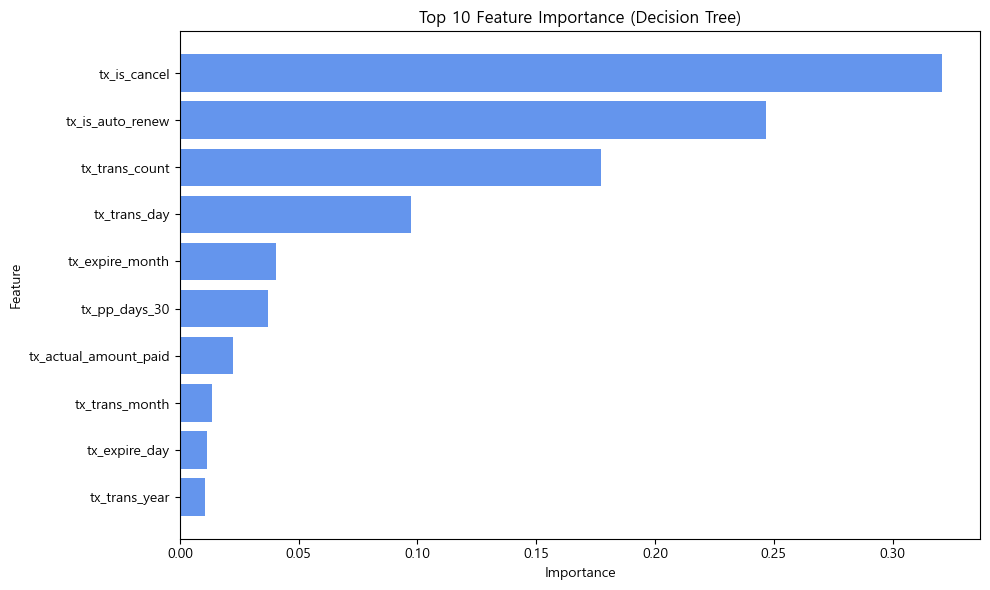

,Feature,Importance
15,tx_is_cancel,0.320795
14,tx_is_auto_renew,0.246906
27,tx_trans_count,0.177239
18,tx_trans_day,0.097225
21,tx_expire_month,0.040507
26,tx_pp_days_30,0.037157
13,tx_actual_amount_paid,0.022230
17,tx_trans_month,0.013424
22,tx_expire_day,0.011587
16,tx_trans_year,0.010357


In [14]:

# 그래프
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"], top10["Importance"], color='cornflowerblue')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (Decision Tree)")
plt.gca().invert_yaxis()  # 가장 중요한 변수가 위로 오게
plt.tight_layout()
plt.savefig("results/feature_importance_dt.png", dpi=300, bbox_inches='tight')
plt.show()

top10.head(20)


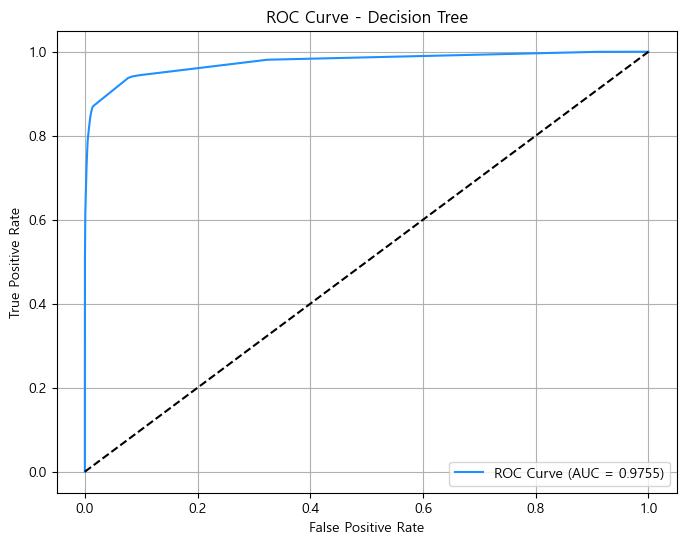

In [16]:

# ### 5. ROC Curve 시각화

# %%
# ROC Curve 계산
fpr, tpr, thresholds = roc_curve(y_val, pred_proba_val)

# AUC 계산
auc_score = roc_auc_score(y_val, pred_proba_val)

# 그래프
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color='dodgerblue',
    label=f"ROC Curve (AUC = {auc_score:.4f})"
)

# 랜덤 모델 기준선
plt.plot([0, 1], [0, 1], linestyle="--", color='black')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")

plt.grid(True)
plt.savefig("results/roc_curve_dt.png", dpi=300, bbox_inches='tight')
plt.show()


In [18]:
print("Decision Tree ROC-AUC:", roc_auc_score(y_val, pred_proba_val))

Decision Tree ROC-AUC: 0.9755234570154963


In [20]:

# ### 6. 리포트 내보내기 (Classification Report)

# %%
report = classification_report(
    y_val,
    pred_val,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "decision_tree_classification_report.csv",
    encoding="utf-8-sig"
)

report_df
    

,precision,recall,f1-score,support
0,0.995259,0.923729,0.958161,154318.000000
1,0.461253,0.936872,0.618164,10756.000000
accuracy,0.924585,0.924585,0.924585,0.924585
macro avg,0.728256,0.930301,0.788162,165074.000000
weighted avg,0.960464,0.924585,0.936007,165074.000000


In [21]:
# ### 4. 피처 중요도 (Feature Importance) 시각화

# %%
# 중요도 추출
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})


# 중요도 순 정렬 후 상위 10개 선택
top10 = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(10)
)


In [22]:

# ### 7. 모델 성능 CSV 저장

from sklearn.metrics import log_loss, roc_auc_score, f1_score
import os

# 성능 지표 계산
logloss = log_loss(y_val, pred_proba_val)
auc = roc_auc_score(y_val, pred_proba_val)
f1 = f1_score(y_val, pred_val)


In [23]:

# DataFrame 생성 (Model 이름 지정)
result_perf = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Log Loss": [logloss],
    "AUC": [auc],
    "F1": [f1]
})


In [28]:

# 폴더 및 파일 경로 설정
os.makedirs("results", exist_ok=True)
save_path = "results/dt_performance.csv"

# CSV 파일로 저장 (기존 파일이 있으면 이어서 추가, 없으면 새로 작성)
if os.path.exists(save_path):
    result_perf.to_csv(save_path, mode='w', header=True, index=False, encoding="utf-8-sig")
    print(f"새로운 내용으로 {save_path} 파일이 덮어씌워져 저장되었습니다.")
else:
    result_perf.to_csv(save_path, mode='w', header=True, index=False, encoding="utf-8-sig")
    print(f"새로운 {save_path} 파일로 저장되었습니다.")

# 저장된 데이터 확인
result_perf

새로운 results/dt_performance.csv 파일로 저장되었습니다.


,Model,Log Loss,AUC,F1
0,Decision Tree (Val),0.152269,0.975523,0.618164
